In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
tr = pd.read_csv("data/thermal_log.csv", header=None)
print(tr.shape)
print(tr.dtypes.value_counts())
tr.head()

(2360, 6)
str    6
Name: count, dtype: int64


,0,1,2,3,4,5
0,timestamp,ms,t_in,h_in,t_out,h_out
1,2026-09-03T14:41:35,2040,30.50,44.20,31.80,32.00
2,2026-09-03T14:41:37,4040,30.50,43.20,31.80,32.00
3,2026-09-03T14:41:39,6040,30.50,44.70,31.80,32.00
4,2026-09-03T14:41:41,8040,30.50,44.70,31.80,32.00


In [4]:
tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2360 entries, 0 to 2359
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       2360 non-null   str  
 1   1       2360 non-null   str  
 2   2       2360 non-null   str  
 3   3       2360 non-null   str  
 4   4       2360 non-null   str  
 5   5       2360 non-null   str  
dtypes: str(6)
memory usage: 110.8 KB


In [10]:
d = pd.read_csv("data/thermal_log.csv", parse_dates=["timestamp"])
print(d.shape)
print(d.dtypes)
print(d.head())

(2359, 6)
timestamp    datetime64[us]
ms                    int64
t_in                float64
h_in                float64
t_out               float64
h_out               float64
dtype: object
            timestamp     ms  t_in  h_in  t_out  h_out
0 2026-09-03 14:41:35   2040  30.5  44.2   31.8   32.0
1 2026-09-03 14:41:37   4040  30.5  43.2   31.8   32.0
2 2026-09-03 14:41:39   6040  30.5  44.7   31.8   32.0
3 2026-09-03 14:41:41   8040  30.5  44.7   31.8   32.0
4 2026-09-03 14:41:43  10040  30.5  44.7   31.8   32.0


In [11]:
d["t"] = (d.ms - d.ms.iloc[0]) / 1000

dt = d.ms.diff().dropna() / 1000
print(dt.value_counts().to_string())
print("\nduration:", d.t.iloc[-1], "s =", round(d.t.iloc[-1]/60, 1), "min")
print("expected samples:", int(d.t.iloc[-1]/2) + 1, "| actual:", len(d))

ms
2.0    2358

duration: 4716.0 s = 78.6 min
expected samples: 2359 | actual: 2359


In [12]:
d["t_pc"] = (d.timestamp - d.timestamp.iloc[0]).dt.total_seconds()
print((d.t - d.t_pc).describe().round(3).to_string())

count    2359.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0


In [13]:
print(d[["t_in","h_in","t_out","h_out"]].describe().round(2).to_string())

          t_in     h_in    t_out    h_out
count  2359.00  2359.00  2359.00  2359.00
mean     25.97    47.74    30.60    33.59
std      24.57    32.84     2.69     2.85
min     -99.00   -99.00   -99.00   -99.00
25%      28.90    44.70    30.25    33.00
50%      30.50    48.00    30.80    34.00
75%      32.20    51.90    30.80    34.00
max      39.10    99.90    31.80    35.00


In [14]:
bad_in  = (d.t_in == -99)
bad_out = (d.t_out == -99)

print("t_in only :", (bad_in & ~bad_out).sum())
print("t_out only:", (~bad_in & bad_out).sum())
print("both      :", (bad_in & bad_out).sum())

print("\nt_in vs h_in aligned:", (bad_in == (d.h_in == -99)).all())

runs = (bad_in != bad_in.shift()).cumsum()[bad_in]
print("\nfailure blocks in t_in:")
print(d[bad_in].groupby(runs)["t"].agg(["min","max","size"]).to_string())

t_in only : 87
t_out only: 1
both      : 0

t_in vs h_in aligned: True

failure blocks in t_in:
         min     max  size
t_in                      
2     3786.0  3842.0    29
4     4086.0  4142.0    29
6     4386.0  4442.0    29


In [15]:
import numpy as np

c = d.copy()
c.loc[c.t_in  == -99, ["t_in", "h_in"]]  = np.nan
c.loc[c.t_out == -99, ["t_out", "h_out"]] = np.nan

print(c[["t_in","h_in","t_out","h_out"]].describe().round(2).to_string())

          t_in     h_in    t_out    h_out
count  2272.00  2272.00  2358.00  2358.00
mean     30.76    53.36    30.65    33.64
std       2.36    16.22     0.30     0.80
min      25.40    37.00    30.20    32.00
25%      29.10    44.90    30.30    33.00
50%      30.50    48.10    30.80    34.00
75%      32.30    52.00    30.80    34.00
max      39.10    99.90    31.80    35.00


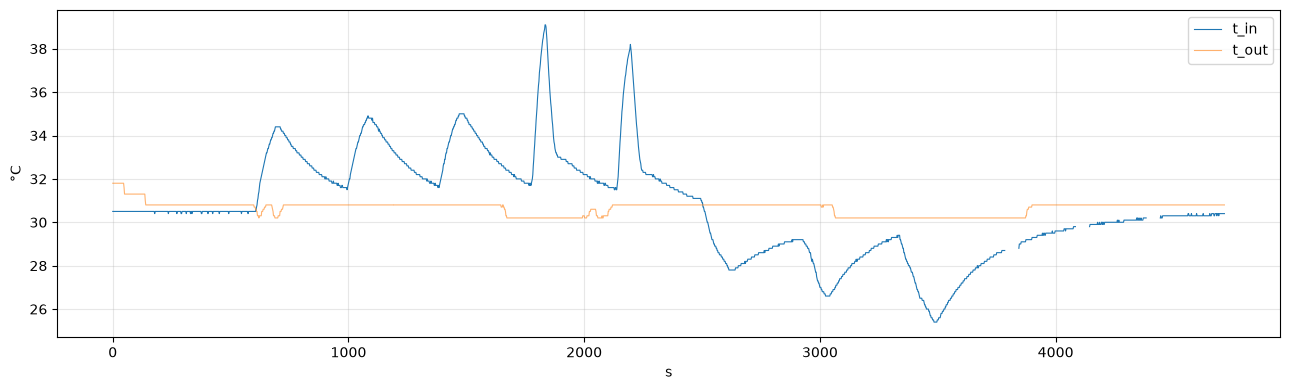

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(c.t, c.t_in, lw=.8, label="t_in")
ax.plot(c.t, c.t_out, lw=.8, alpha=.6, label="t_out")
ax.set_xlabel("s"); ax.set_ylabel("°C")
ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

In [17]:
windows = [(600, 900), (960, 1300), (1350, 1700),
           (1750, 2100), (2100, 2450)]

peaks = []
for a, z in windows:
    w = c[(c.t >= a) & (c.t <= z)].dropna(subset=["t_in"])
    i = w.t_in.idxmax()
    peaks.append((c.t[i], c.t_in[i]))
    print(f"[{a:>5},{z:>5}]  peak t={c.t[i]:>7.0f}s  T={c.t_in[i]:.2f}")

[  600,  900]  peak t=    690s  T=34.40
[  960, 1300]  peak t=   1082s  T=34.90
[ 1350, 1700]  peak t=   1470s  T=35.00
[ 1750, 2100]  peak t=   1834s  T=39.10
[ 2100, 2450]  peak t=   2196s  T=38.20


In [18]:
troughs = [(2450, 2800), (2850, 3200), (3250, 3600)]

for a, z in troughs:
    w = c[(c.t >= a) & (c.t <= z)].dropna(subset=["t_in"])
    i = w.t_in.idxmin()
    print(f"[{a:>5},{z:>5}]  trough t={c.t[i]:>7.0f}s  T={c.t_in[i]:.2f}")

[ 2450, 2800]  trough t=   2614s  T=27.80
[ 2850, 3200]  trough t=   3024s  T=26.60
[ 3250, 3600]  trough t=   3484s  T=25.40


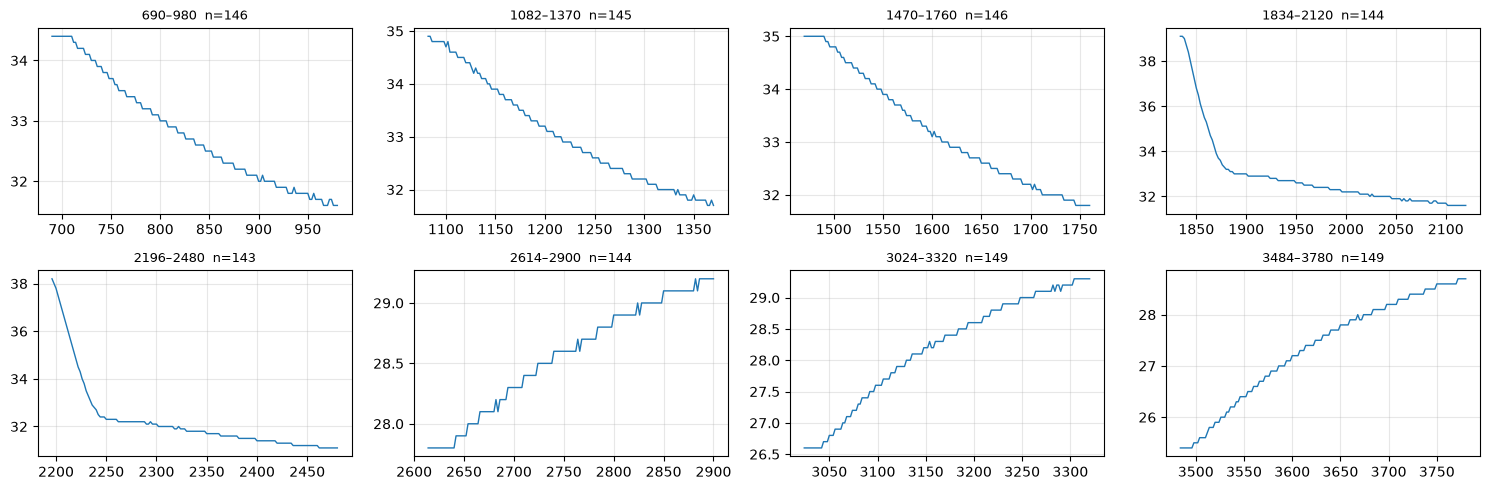

In [19]:
segs = [(690, 980),    # بعد المسك ١
        (1082, 1370),  # بعد المسك ٢
        (1470, 1760),  # بعد المسك ٣
        (1834, 2120),  # بعد اللهب ١
        (2196, 2480),  # بعد اللهب ٢
        (2614, 2900),  # بعد البارد ١
        (3024, 3320),  # بعد البارد ٢
        (3484, 3780)]  # بعد البارد ٣

fig, axes = plt.subplots(2, 4, figsize=(15, 5), sharey=False)
for (a, z), ax in zip(segs, axes.ravel()):
    w = c[(c.t >= a) & (c.t <= z)].dropna(subset=["t_in"])
    ax.plot(w.t, w.t_in, lw=1)
    ax.set_title(f"{a}–{z}  n={len(w)}", fontsize=9)
    ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [20]:
from scipy.optimize import curve_fit

def expo(t, A, tau, C):
    return A * np.exp(-t / tau) + C

names = ["مسك ١","مسك ٢","مسك ٣","لهب ١","لهب ٢","بارد ١","بارد ٢","بارد ٣"]
res = []

for (a, z), nm in zip(segs, names):
    w = c[(c.t >= a) & (c.t <= z)].dropna(subset=["t_in"])
    x = (w.t - w.t.iloc[0]).values
    y = w.t_in.values

    p0 = [y[0] - y[-1], 100, y[-1]]
    p, _ = curve_fit(expo, x, y, p0=p0, maxfev=20000)

    rmse = np.sqrt(np.mean((y - expo(x, *p))**2))
    res.append((nm, p[1], p[0], p[2], rmse))
    print(f"{nm:>7} | tau={p[1]:>7.1f}s | A={p[0]:>7.2f} | C={p[2]:>6.2f} | RMSE={rmse:.3f}")

  مسك ١ | tau=  243.9s | A=   4.43 | C= 30.21 | RMSE=0.054
  مسك ٢ | tau=  239.0s | A=   4.83 | C= 30.24 | RMSE=0.051
  مسك ٣ | tau=  271.0s | A=   5.42 | C= 29.86 | RMSE=0.062
  لهب ١ | tau=   30.5s | A=   7.68 | C= 32.04 | RMSE=0.303
  لهب ٢ | tau=   29.9s | A=   7.16 | C= 31.49 | RMSE=0.266
 بارد ١ | tau=  326.0s | A=  -2.65 | C= 30.33 | RMSE=0.038
 بارد ٢ | tau=  203.2s | A=  -3.86 | C= 30.23 | RMSE=0.052
 بارد ٣ | tau=  216.6s | A=  -4.76 | C= 29.94 | RMSE=0.046


In [21]:
tau_slow = np.mean([243.9, 239.0, 271.0])   # من مقاطع المسك
print("tau_slow fixed at", round(tau_slow, 1), "s")

def expo2_fixed(t, A1, tau1, A2, C):
    return A1*np.exp(-t/tau1) + A2*np.exp(-t/tau_slow) + C

for (a, z), nm in zip(segs[3:5], ["لهب ١", "لهب ٢"]):
    w = c[(c.t >= a) & (c.t <= z)].dropna(subset=["t_in"])
    x = (w.t - w.t.iloc[0]).values
    y = w.t_in.values

    p1, _ = curve_fit(expo, x, y, p0=[y[0]-y[-1], 30, y[-1]], maxfev=20000)
    r1 = np.sqrt(np.mean((y - expo(x, *p1))**2))

    p2, _ = curve_fit(expo2_fixed, x, y,
                      p0=[y[0]-y[-1], 30, 0.5, y[-1]], maxfev=40000)
    r2 = np.sqrt(np.mean((y - expo2_fixed(x, *p2))**2))

    print(f"\n{nm}")
    print(f"  order 1 | tau={p1[1]:6.1f} | RMSE={r1:.3f}")
    print(f"  order 2 | tau_fast={p2[1]:6.1f} | A_fast={p2[0]:5.2f} | A_slow={p2[2]:5.2f} | RMSE={r2:.3f}")
    print(f"  RMSE ratio: {r1/r2:.2f}x")

tau_slow fixed at 251.3 s

لهب ١
  order 1 | tau=  30.5 | RMSE=0.303
  order 2 | tau_fast=  21.1 | A_fast= 6.82 | A_slow= 2.47 | RMSE=0.206
  RMSE ratio: 1.47x

لهب ٢
  order 1 | tau=  29.9 | RMSE=0.266
  order 2 | tau_fast=  21.8 | A_fast= 6.41 | A_slow= 2.06 | RMSE=0.193
  RMSE ratio: 1.38x
